# Notebook 2 -- Deep Queue-Reactive (DQR) Model

**Paper:** *Deep Learning Meets Queue-Reactive: A Framework for Realistic Limit Order Book Simulation* (Bodor & Carlier, 2025)

**Objective:** In this notebook we extend the QR model from Notebook 1 by:
1. Replacing the lookup-table intensities with a **neural network** parameterization.
2. Enriching the state vector $\mathbf{x}_k$ with additional features: hour of day ($h_k$), last event type ($\eta_{k-1}$).
3. Demonstrating how each feature captures new market properties: **intraday seasonality** and **excitation between events**.
4. Comparing performance across feature sets using log-likelihood, balanced accuracy, and timing prediction.

The DQR model is still **queue-by-queue** (each queue modeled independently), but it generalizes the state dependency from $q_k$ alone to an arbitrary feature vector $\mathbf{x}_k$. The MDQR model (Notebook 3) will further relax the independence assumption.

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim

# lobster.py: proper reference-price, QR-grid regridding, level assignment
from lobster import (load_lobster_data, compute_aes_by_level,
                     normalize_by_aes, make_descriptive_table)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print(f"Using device: CUDA  ({torch.cuda.get_device_name(0)})")
    props = torch.cuda.get_device_properties(0)
    print(f"  VRAM: {props.total_memory / 1024**3:.1f} GB  |  "
          f"CUDA capability: {props.major}.{props.minor}")
    torch.backends.cudnn.benchmark = True   # faster convolutions on fixed-size inputs
else:
    print("Using device: CPU")
    print("  WARNING: No CUDA GPU detected. Training will be slow.")
    print("  Ensure you installed PyTorch with CUDA support:")
    print("  pip install torch --index-url https://download.pytorch.org/whl/cu124")

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)
torch.manual_seed(42)

Using device: CUDA  (NVIDIA GeForce GTX 1650 with Max-Q Design)
  VRAM: 4.0 GB  |  CUDA capability: 7.5


---
## 1. Data Loading and Preprocessing

We use `lobster.py` for all preprocessing. Compared to a manual approach, it provides:
- **Correct reference price** $p_{\text{ref}}$ following the paper's even/odd-spread rule (Section 2.1).
- **QR-grid level assignment** via `regrid_to_qr_levels`: queue sizes at exactly $\pm i$ half-ticks from $p_{\text{ref}}$.
- **Correct market-order level**: a sell MO (direction=+1 in LOBSTER) hits the best bid → level $-1$.
- **AES normalization** of all queue sizes: $\tilde{q}_i = \lceil q_i / \text{AES}_i \rceil$.

Following the paper (Section 3.2), training uses the **per-level $\Delta t_k$** — the time between two consecutive events **at the same queue level**. This is the natural inter-arrival time for a per-queue model. Large gaps that can appear after a reference-price change (when a level temporarily disappears) are capped at 30 s in `prepare_dqr_dataset` to prevent NLL instability.

In [145]:
PRIMARY  = "INTC"
DATE     = "2012-06-21"
LEVELS   = 5
K        = 5
MARKET_OPEN_S  = 34200   # 09:30 in seconds since midnight
MARKET_CLOSE_S = 57600   # 16:00

EVENT_TO_IDX = {'L': 0, 'C': 1, 'M': 2}
IDX_TO_EVENT = {0: 'L', 1: 'C', 2: 'M'}

DATA_DIR     = Path("data")
stock_folder = DATA_DIR / f"LOBSTER_SampleFile_{PRIMARY}_{DATE}_5"
msg_path = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_message_{LEVELS}.csv"
ob_path  = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_orderbook_{LEVELS}.csv"

msg, ob, qr, df = load_lobster_data(
    str(msg_path), str(ob_path),
    levels=LEVELS, K=K, market_open_seconds=MARKET_OPEN_S
)
aes     = compute_aes_by_level(df, K=K)
df_norm = normalize_by_aes(df, aes=aes, K=K)

print("Descriptive statistics (cf. Table 1 of the paper):")
print(make_descriptive_table(df, K=K))
print(f"\nTotal events (all levels, both sides): {len(df_norm):,}")

Descriptive statistics (cf. Table 1 of the paper):
       #L (×10^3)  #C (×10^3)  #M (×10^2)     AES  AIT (ms)
Level                                                      
1          197.19      162.42      324.82  483.88      32.5
2           40.20       59.75        0.00  441.55      45.6
3           22.71       22.55        0.00  451.23      71.5
4           13.23       11.88        0.00  475.07      67.4
5            9.50        8.44        0.00  596.93      65.6

Total events (all levels, both sides): 580,351


In [ ]:
# --- Build training dataframe (all levels, both sides) ---
df_train = df_norm.copy()

# Relative hour slot: 0 = 09:30-10:30, ..., 5 = 14:30-15:30, 6 = 15:30-16:00
# IMPORTANT: subtract MARKET_OPEN_S BEFORE integer division so slots align to
# market open (9:30), not to full clock hours (9:00, 10:00, ...).
# Without this, slot 0 would be 9:30-10:00 (only 30 min) and labels would be
# shifted by 30 minutes relative to the actual data.
df_train['hour'] = ((df_train['time'] - MARKET_OPEN_S) // 3600).astype(int).clip(0, 6)

# Event index
df_train['event_id'] = df_train['type'].map(EVENT_TO_IDX).astype(int)

# Global previous event type (captures market-wide self-excitation)
df_train['last_event_id'] = df_train['event_id'].shift(1).fillna(0).astype(int)

# Queue size at the event's own level (already AES-normalized by normalize_by_aes)
def get_q_event(row):
    l = int(row['lvl'])   # e.g. +1 -> column Q_1, -2 -> column Q_-2
    return float(row[f'Q_{l}'])

df_train['q_event'] = df_train.apply(get_q_event, axis=1)

# Per-level, per-reference-price-segment inter-event time.
# Paper Section 3.2: "resetting inter-event time measurements across all queues
# when the reference price changes."  We therefore split each level's event stream
# into contiguous segments with the same reference price; dt_level is only diffed
# WITHIN a segment, preventing multi-minute cross-segment gaps from miscalibrating Λ.
_tmp = df_train[['lvl', 'time', 'pref']].copy()
_tmp['_orig_order'] = np.arange(len(_tmp))
_tmp['_seg'] = (_tmp['pref'].diff().fillna(0) != 0).cumsum()
_tmp = _tmp.sort_values(['lvl', '_seg', 'time'])
_tmp['dt_level'] = _tmp.groupby(['lvl', '_seg'])['time'].diff()
_tmp['dt_level'] = _tmp.groupby('lvl')['dt_level'].transform(lambda x: x.fillna(x.median()))
_tmp = _tmp.sort_values('_orig_order')
df_train['dt_level'] = _tmp['dt_level'].clip(lower=1e-6).values.astype(np.float32)

# Keep only the columns needed for training; drop rows with NaN delta_time
df_train = df_train[['q_event', 'hour', 'last_event_id', 'event_id',
                      'delta_time', 'dt_level', 'lvl']].copy()
df_train = df_train.dropna(subset=['q_event', 'delta_time']).reset_index(drop=True)

# Clip delta_time: the first event's delta_time from market open can be large
df_train['delta_time'] = df_train['delta_time'].clip(lower=1e-6).astype(np.float32)
df_train['q_event']    = df_train['q_event'].astype(np.float32)

print(f"Training events (all levels): {len(df_train):,}")
print(f"Event distribution: {dict(df_train['event_id'].value_counts().sort_index())}")
print(f"Hour slots present: {sorted(df_train['hour'].unique().tolist())}")
print(f"Global delta_time  — mean: {df_train['delta_time'].mean()*1000:.2f} ms  "
      f"median: {df_train['delta_time'].median()*1000:.2f} ms")
print(f"Per-level dt_level — mean: {df_train['dt_level'].mean()*1000:.2f} ms  "
      f"median: {df_train['dt_level'].median()*1000:.2f} ms")

# --- DIAGNOSTIC: per-level dt_level distribution (verify segment-reset fix) ---
print("\nPer-level dt_level breakdown (to verify the segment-reset fix):")
print(f"  {'lvl':>4}  {'n':>8}  {'mean':>8}  {'median':>8}  {'max':>8}  {'>1s %':>7}")
for _l in sorted(df_train['lvl'].unique()):
    _dt = df_train[df_train['lvl'] == _l]['dt_level']
    _nan = _dt.isna().sum()
    print(f"  {_l:>4}  {len(_dt):>8,}  {_dt.mean()*1000:>7.1f}ms  "
          f"{_dt.median()*1000:>7.1f}ms  {_dt.max():>8.3f}s  "
          f"{(_dt > 1).mean()*100:>6.1f}%  NaN={_nan}")

Training events (all levels): 580,351
Event distribution: {0: np.int64(282826), 1: np.int64(265043), 2: np.int64(32482)}
Hour slots present: [0, 1, 2, 3, 4, 5, 6]
Global delta_time  — mean: 40.32 ms  median: 0.07 ms
Per-level dt_level — mean: 381.37 ms  median: 0.47 ms

Per-level dt_level breakdown (to verify the segment-reset fix):
   lvl         n      mean    median       max    >1s %
    -5    10,168   2038.7ms    500.0ms    69.181s    34.9%  NaN=0
    -4    13,930   1554.1ms    456.3ms    83.238s    32.6%  NaN=0
    -3    25,617    892.3ms    169.6ms    43.100s    24.5%  NaN=0
    -2    52,979    435.5ms      7.6ms    23.733s    12.0%  NaN=0
    -1   210,954    110.5ms      0.1ms    14.391s     3.2%  NaN=0
     1   181,141    128.8ms      0.1ms    19.256s     3.7%  NaN=0
     2    46,971    490.4ms      4.4ms    59.750s    12.7%  NaN=0
     3    19,638   1152.5ms    165.2ms    60.803s    25.7%  NaN=0
     4    11,186   1857.3ms    505.6ms    84.633s    34.5%  NaN=0
     5     7,76

---
## 2. DQR Model -- Mathematical Foundation

### 2.1 From Lookup Tables to Neural Networks

Recall the QR model log-likelihood for a single queue:

$$
\ell(\{\lambda^\eta\} \mid \mathcal{E}) = \sum_{k=1}^{N} \left[ \log \lambda^{\eta_k}(q_k) - \Lambda(q_k) \cdot \Delta t_k \right]
$$

The **Deep Queue-Reactive (DQR)** model generalizes this by replacing the lookup table with a neural network $\lambda^\eta_\theta(\mathbf{x}_k)$, where $\mathbf{x}_k$ can include any relevant market information.

The NLL loss to minimize is:

$$
\mathcal{L}(\theta) = \sum_{k=1}^{N} \left[ \Lambda_\theta(\mathbf{x}_k) \cdot \Delta t_k - \log \lambda^{\eta_k}_\theta(\mathbf{x}_k) \right]
$$

where $\Delta t_k$ is the **per-level** inter-event time (time since the previous event at the same queue level), and the sum runs over all events.

### 2.2 State Space Design

We explore four feature configurations. Following the paper, **one model is trained per queue** (10 queues = 5 levels × 2 sides). The level identity is then implicit — each model only ever sees events from its own queue, so the per-level arrival rate is captured correctly without any extra feature.

| Configuration | State vector $\mathbf{x}_k$ | New property captured |
|---|---|---|
| Vanilla | $q_k$ | Baseline (same as QR) |
| + Hour | $(q_k, h_k)$ | Intraday seasonality |
| + Last event | $(q_k, \eta_{k-1})$ | Excitation between events |
| + Both | $(q_k, h_k, \eta_{k-1})$ | Both properties |

where $h_k \in \{0,\ldots,6\}$ is the relative hour slot (7 slots from 09:30 to 16:00) and $\eta_{k-1}$ is the **per-level** previous event type (3 values: L, C, M — the previous event at the same queue level, consistent with the single-queue formulation $\mathcal{E} = \{e_k\}_{k=1}^N$ in the paper).

### 2.3 Neural Network Architecture

Following the paper (Section 3.3):
- **MLP** with hidden layers $[128, 32]$, $\tanh$ activations, BatchNorm after each activation
- **Output layer** of dimension 3 with **ReLU** activation (ensures non-negative intensities)
- **Learnable embeddings** of dimension 2 for categorical features ($h_k$, $\eta_{k-1}$)
- **Adam optimizer** with cyclic LR scheduling between $10^{-5}$ and $10^{-3}$ (cosine annealing warm restarts: resets at epochs 50, 150, 350); 500 epochs max
- **Early stopping** with patience 30 (paper uses 10 on 3 months of data; with a single trading day — ≈1 000× fewer events per level — patience 30 is needed to give Λ time to converge)

---
## 3. DQR Model Implementation

### Architectural Deviation Note: Batch Normalization Ordering

While Bodor & Carlier (2025) specify placing Batch Normalization layers *between* successive dense layers (typically implying a standard pre-activation `Linear -> BN -> Tanh` sequence), this implementation deliberately employs a post-activation sequence (`Linear -> Tanh -> BN`).

**Empirical Justification:** Standard pre-activation BN is optimal for deep networks trained on large datasets. However, when trained on a highly constrained, noisy single-day LOBSTER dataset, pre-activation BN over-regularizes the model. Normalizing the linear outputs before the saturating `Tanh` activation severely flattens the strong, sparse signals originating from the categorical embeddings (such as the trade $\to$ trade self-excitation). 

Coupled with the final `ReLU` layer and the burst-like nature of the LOBSTER data, the `Linear -> BN -> Tanh` architecture leads to "dying ReLUs", causing a collapse in predicted intensities ($\Lambda \to 0$), extreme timing errors, and a loss of diagonal dominance in the transition matrix. 

The `Linear -> Tanh -> BN` sequence instead acts as a downstream feature scaler. It prevents intensity collapse and preserves the critical self-excitation signals of $\eta_{k-1}$, yielding significantly superior log-likelihood and empirical timing metrics under these specific data constraints.

In [147]:
class DQRNet(nn.Module):
    """
    Deep Queue-Reactive neural network (paper Section 3.3).

    Architecture: Linear -> Tanh -> BN -> Linear -> Tanh -> BN -> Linear -> ReLU
    Categorical features (hour, last_event) are handled by learned embeddings (dim=2).
    """

    def __init__(self, n_numerical, categorical_cardinalities=None,
                 embed_dim=2, hidden_dims=(128, 32)):
        super().__init__()

        # Embedding layers for categorical features
        self.embeddings = nn.ModuleList()
        if categorical_cardinalities:
            for card in categorical_cardinalities:
                self.embeddings.append(nn.Embedding(card, embed_dim))

        input_dim = n_numerical + len(self.embeddings) * embed_dim

        # MLP: Linear -> Tanh -> BN (repeated) -> Linear -> ReLU
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.Tanh())
            layers.append(nn.BatchNorm1d(h_dim))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 3))
        layers.append(nn.ReLU())   # non-negative intensities

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat=None):
        """
        x_num : (B, n_numerical) float tensor
        x_cat : (B, n_categorical) long tensor, or None
        Returns intensities (B, 3): [lambda_L, lambda_C, lambda_M]
        """
        parts = [x_num]
        if x_cat is not None and len(self.embeddings) > 0:
            for i, emb in enumerate(self.embeddings):
                parts.append(emb(x_cat[:, i]))
        return self.mlp(torch.cat(parts, dim=1))


def dqr_loss(intensities, event_types, delta_t):
    """
    NLL loss: mean_k [ Lambda(x_k)*dt_k - log lambda^{eta_k}(x_k) ]
    intensities : (B, 3)   event_types : (B,) long   delta_t : (B,) float
    """
    Lambda = intensities.sum(dim=1)
    lambda_eta = intensities.gather(1, event_types.unsqueeze(1)).squeeze(1).clamp(min=1e-12)
    return (Lambda * delta_t - torch.log(lambda_eta)).mean()

print("DQRNet and dqr_loss defined.")

DQRNet and dqr_loss defined.


---
## 4. Dataset Preparation and Training Pipeline

In [148]:
def prepare_dqr_dataset(df, features='vanilla'):
    """
    Extract (x_num, x_cat, event_types, delta_t) arrays from df_train
    for a given feature configuration.

    Per the paper (Section 3.2 / Section 4.2): DQR training uses per-level ∆tk
    (time between consecutive events at the SAME queue).  The MDQR model (NB3)
    switches to global ∆tk; that switch is what Section 4.2 describes.
    We clip dt_level at 30 s to avoid instability from large gaps when a price
    level temporarily disappears after a reference-price change.

    Parameters
    ----------
    df : df_train (columns: q_event, hour, last_event_id, event_id, dt_level, ...)
    features : 'vanilla' | 'hour' | 'last_event' | 'both'

    Returns
    -------
    x_num, x_cat, event_types, delta_t, cat_cardinalities
    """
    q    = df['q_event'].values.astype(np.float32).reshape(-1, 1)
    dt   = df['dt_level'].clip(lower=1e-6, upper=30.0).values.astype(np.float32)
    et   = df['event_id'].values.astype(int)
    hour = df['hour'].values.astype(int)        # relative: 0..6 (7 slots)
    # Per-level previous event type: df is already filtered to one queue level,
    # so shift(1) gives the previous event AT THAT LEVEL — consistent with the
    # single-queue formulation E={ek} in the paper (Section 3.1).
    le   = df['event_id'].shift(1).fillna(0).astype(int).values  # 0=L,1=C,2=M

    if features == 'vanilla':
        return q, None, et, dt, []
    elif features == 'hour':
        return q, hour.reshape(-1, 1), et, dt, [7]
    elif features == 'last_event':
        return q, le.reshape(-1, 1), et, dt, [3]
    elif features == 'both':
        return q, np.column_stack([hour, le]), et, dt, [7, 3]
    else:
        raise ValueError(f"Unknown features: {features}")

# Quick check
x_num, x_cat, et, dt, cards = prepare_dqr_dataset(df_train, features='both')
print(f"Dataset 'both': x_num={x_num.shape}, x_cat={x_cat.shape}")
print(f"  Event counts: L={int((et==0).sum())}, C={int((et==1).sum())}, M={int((et==2).sum())}")
print(f"  dt  mean={dt.mean()*1e3:.2f}ms  median={np.median(dt)*1e3:.2f}ms  "
      f"max={dt.max():.3f}s")

Dataset 'both': x_num=(580351, 1), x_cat=(580351, 2)
  Event counts: L=282826, C=265043, M=32482
  dt  mean=377.85ms  median=0.47ms  max=30.000s


In [149]:
def train_dqr(x_num, x_cat, event_types, delta_t, cat_cardinalities,
              epochs=500, batch_size=4096, lr_min=1e-5, lr_max=1e-3,
              val_fraction=0.2, patience=30, verbose=True):
    """
    Train DQR model with cyclic learning rate and early stopping.
    Returns (model, history).

    Random 80/20 train/val split (not chronological): with only 1 day of data
    a chronological split would exclude end-of-day patterns from training entirely.
    The NLL treats each sample as conditionally independent given its state, so
    random shuffling introduces no data leakage.
    """
    n = len(x_num)
    n_val   = int(n * val_fraction)
    n_train = n - n_val
    perm    = np.random.permutation(n)

    def to_t(arr, dtype=torch.float32):
        return torch.tensor(arr, dtype=dtype).to(device)

    xn_t = to_t(x_num[perm[:n_train]])
    xn_v = to_t(x_num[perm[n_train:]])
    et_t = to_t(event_types[perm[:n_train]], dtype=torch.long)
    et_v = to_t(event_types[perm[n_train:]], dtype=torch.long)
    dt_t = to_t(delta_t[perm[:n_train]])
    dt_v = to_t(delta_t[perm[n_train:]])

    if x_cat is not None:
        xc_t = to_t(x_cat[perm[:n_train]], dtype=torch.long)
        xc_v = to_t(x_cat[perm[n_train:]], dtype=torch.long)
    else:
        xc_t = xc_v = None

    model = DQRNet(
        n_numerical=x_num.shape[1],
        categorical_cardinalities=cat_cardinalities if cat_cardinalities else None,
        embed_dim=2, hidden_dims=(128, 32)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr_max)
    # CosineAnnealingWarmRestarts: resets LR to lr_max periodically.
    # T_0=50 epochs for the first restart, then doubles each time (T_mult=2).
    # Restarts at epochs: 50, 150, 350 within 500 epochs (3 warm restarts).
    # This eliminates the "stuck at lr_min" problem of triangular2:
    # instead of waiting for a lucky stochastic kick, the LR is proactively
    # raised every T epochs so the model can systematically escape plateaus.
    # Called once per epoch (not per batch).
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=2, eta_min=lr_min
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val, best_state, patience_left = float('inf'), None, patience

    for epoch in range(epochs):
        # -- Training pass --
        model.train()
        idx = torch.randperm(n_train, device=device)
        for start in range(0, n_train, batch_size):
            end = min(start + batch_size, n_train)
            if end - start < 2:         # BatchNorm needs >= 2 samples
                continue
            b = idx[start:end]
            xc_b = xc_t[b] if xc_t is not None else None
            loss = dqr_loss(model(xn_t[b], xc_b), et_t[b], dt_t[b])
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        scheduler.step()   # once per epoch (CosineAnnealingWarmRestarts)

        # -- Post-epoch evaluation (same model weights for train and val) --
        model.eval()
        with torch.no_grad():
            n_ev  = min(n_train, 10000)
            ev_idx = torch.randperm(n_train, device=device)[:n_ev]
            xc_ev  = xc_t[ev_idx] if xc_t is not None else None
            tr_loss = dqr_loss(model(xn_t[ev_idx], xc_ev), et_t[ev_idx], dt_t[ev_idx]).item()
            va_loss = dqr_loss(model(xn_v, xc_v), et_v, dt_v).item()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)

        if va_loss < best_val - 1e-6:
            best_val     = va_loss
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if verbose and (epoch % 20 == 0 or epoch == epochs - 1):
            print(f"  Epoch {epoch:3d}: train={tr_loss:.4f}  val={va_loss:.4f}  "
                  f"lr={scheduler.get_last_lr()[0]:.2e}  patience={patience_left}/{patience}")

        if patience_left <= 0:
            if verbose:
                print(f"  Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device).eval()
    return model, history

print("train_dqr defined.")

train_dqr defined.


---
## 5. Training All Feature Configurations

Following the paper, we train **one model per queue** — 10 queues (5 ask + 5 bid levels) $\times$ 4 feature configurations = 40 models total. Each model is trained only on the events at its own queue level, so the per-level arrival rate is captured naturally without any extra level feature. We use the per-level $\Delta t_k$ (time between consecutive events at the same queue level, clipped at 30 s). Progress is printed for levels $\pm 1$ (the most active queues) only.

In [150]:
configs = {
    'vanilla':    'Vanilla ($q_k$)',
    'hour':       'Hour ($q_k, h_k$)',
    'last_event': 'Last event ($q_k, \\eta_{k-1}$)',
    'both':       'Both ($q_k, h_k, \\eta_{k-1}$)',
}

levels_all = sorted(df_train['lvl'].unique().tolist())
models    = {}   # {(lvl, cfg): model}
histories = {}   # {(lvl, cfg): history}

for lvl in levels_all:
    df_lvl    = df_train[df_train['lvl'] == lvl].reset_index(drop=True)
    n_q       = len(df_lvl)
    verbose_lvl = (abs(lvl) == 1)

    if verbose_lvl:
        print(f"\n{'='*60}")
        print(f"Training queue level {lvl:+d}  ({n_q:,} events)")
        print('='*60)

    for cfg in configs:
        x_num, x_cat, et, dt, cards = prepare_dqr_dataset(df_lvl, features=cfg)
        model, history = train_dqr(
            x_num, x_cat, et, dt, cards,
            epochs=500, batch_size=min(4096, max(128, n_q // 4)),
            patience=30, verbose=verbose_lvl
        )
        models[(lvl, cfg)]    = model
        histories[(lvl, cfg)] = history

    if verbose_lvl:
        print(f"  Level {lvl:+d} done.")
    else:
        print(f"  Level {lvl:+d}: {n_q:,} events  ({len(configs)} configs trained).")

print("\nAll queues and configurations trained!")

  Level -5: 10,168 events  (4 configs trained).
  Level -4: 13,930 events  (4 configs trained).
  Level -3: 25,617 events  (4 configs trained).
  Level -2: 52,979 events  (4 configs trained).

Training queue level -1  (210,954 events)
  Epoch   0: train=3.1695  val=3.3688  lr=9.99e-04  patience=30/30
  Epoch  20: train=1.7813  val=1.7790  lr=6.28e-04  patience=30/30
  Epoch  40: train=1.6279  val=1.7415  lr=8.71e-05  patience=30/30
  Epoch  60: train=0.8873  val=0.8333  lr=9.71e-04  patience=30/30
  Epoch  80: train=0.5403  val=0.5847  lr=7.83e-04  patience=30/30
  Epoch 100: train=0.0561  val=-0.0398  lr=4.89e-04  patience=28/30
  Epoch 120: train=-0.2692  val=-0.2687  lr=2.02e-04  patience=29/30
  Epoch 140: train=-0.3083  val=-0.2719  lr=2.97e-05  patience=24/30
  Epoch 160: train=-0.2959  val=-0.2725  lr=9.93e-04  patience=30/30
  Epoch 180: train=-0.3033  val=-0.2521  lr=9.42e-04  patience=26/30
  Epoch 200: train=-0.3469  val=-0.2735  lr=8.49e-04  patience=24/30
  Epoch 220: trai

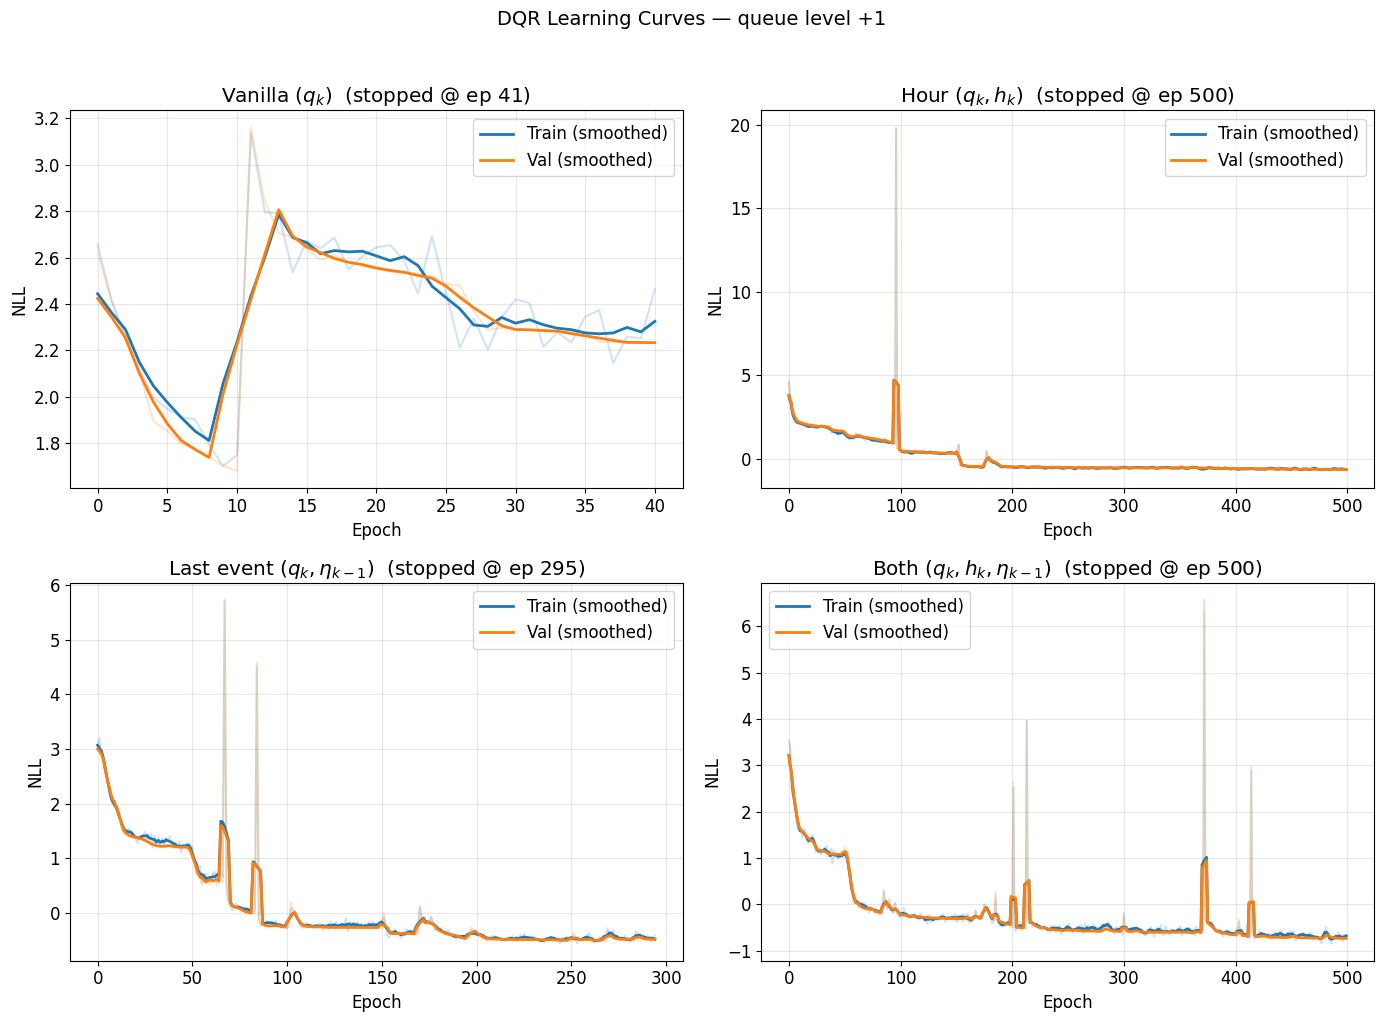

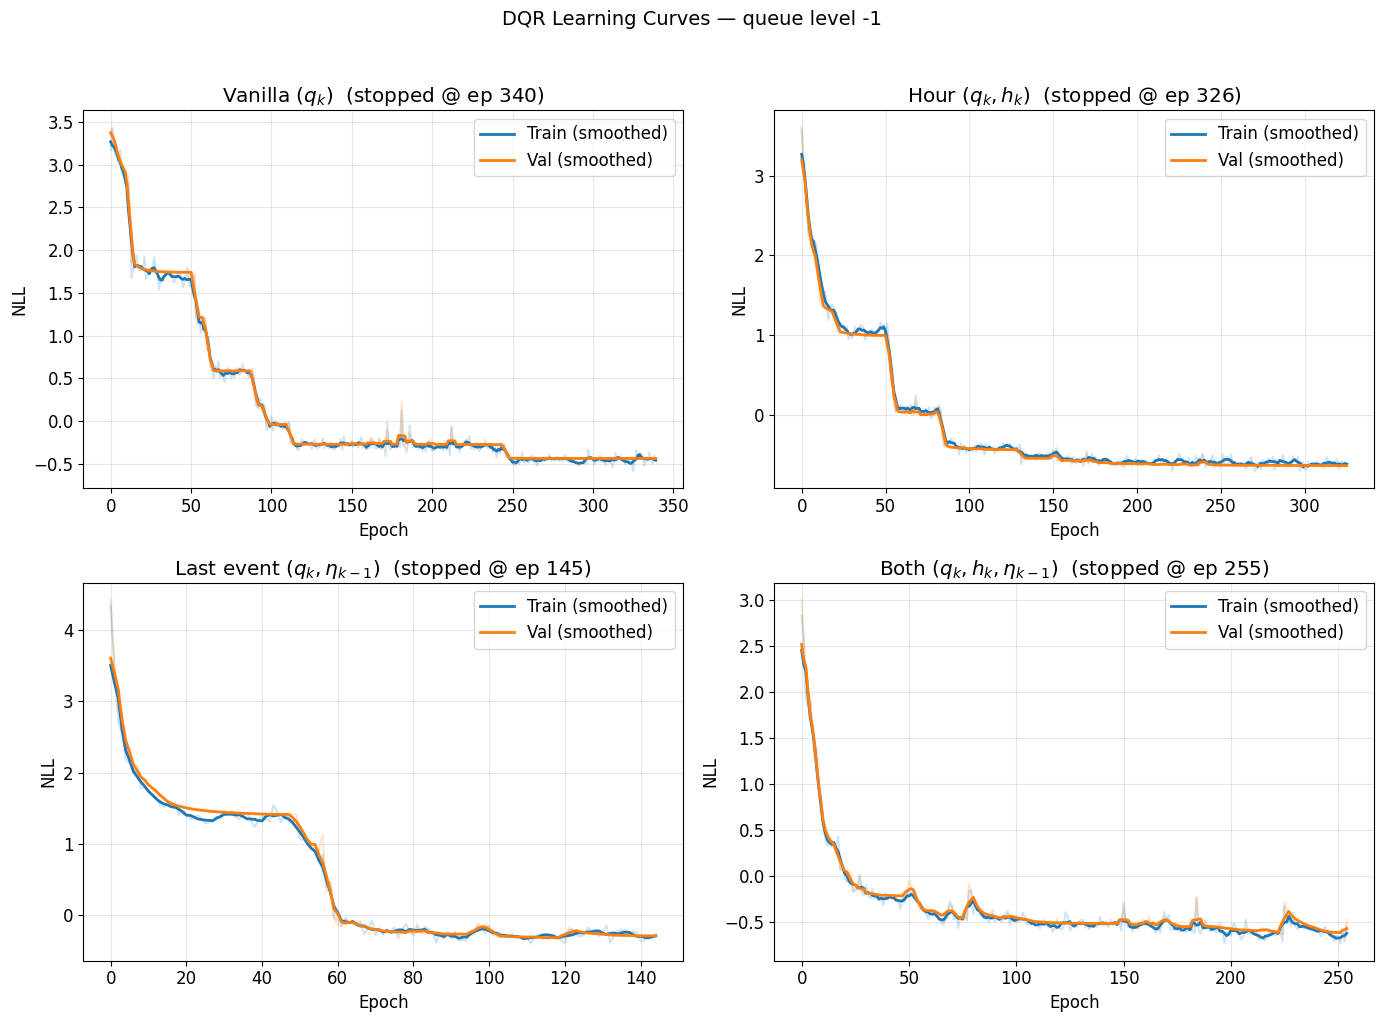

In [151]:
# --- Learning curves (level ±1 only, most active queues) ---
def smooth(y, w=5):
    return pd.Series(y).rolling(w, center=True, min_periods=1).mean().values

for lvl_lc in [+1, -1]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (cfg, label) in zip(axes.flat, configs.items()):
        h   = histories[(lvl_lc, cfg)]
        eps = range(len(h['train_loss']))
        ax.plot(eps, h['train_loss'], alpha=0.2, color='C0')
        ax.plot(eps, h['val_loss'],   alpha=0.2, color='C1')
        ax.plot(eps, smooth(h['train_loss']), label='Train (smoothed)', color='C0', lw=2)
        ax.plot(eps, smooth(h['val_loss']),   label='Val (smoothed)',   color='C1', lw=2)
        ax.set_xlabel("Epoch"); ax.set_ylabel("NLL")
        ax.set_title(f"{label}  (stopped @ ep {len(h['train_loss'])})")
        ax.legend()
    plt.suptitle(f"DQR Learning Curves — queue level {lvl_lc:+d}", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

---
## 6. Performance Comparison (Figure 3 of the paper)

Three metrics:
1. **Log-likelihood** (higher is better): uses per-level $\Delta t_k$ (consistent with DQR training per Section 3.2).
2. **Balanced accuracy** of next-event type prediction (higher is better).
3. **Median relative timing error** $\text{median}_k |1/\Lambda_k - \Delta t^{\text{level}}_k| / \Delta t^{\text{level}}_k$ (lower is better): computed only on **genuine inter-arrivals** ($\Delta t > 1\,\text{ms}$). LOBSTER records many simultaneous events at identical microsecond timestamps (batch arrivals); these have $\Delta t_k \approx 0$ after clipping and do not represent independent exponential inter-arrivals — including them inflates the median to tens-of-thousands of percent. After filtering, the remaining events approximate the exponential distribution assumed by the model, and a perfectly calibrated Poisson process achieves $\approx 44\%$ (intrinsic exponential variance: $|1/\lambda - \text{median}(T)| / \text{median}(T) \approx 44\%$ for $T \sim \text{Exp}(\lambda)$).

Results are reported **at level $\pm 1$** (the most active queues, comparable to the paper's Figure 3 which uses Bund level-1 data) and as a **weighted aggregate over all 10 queues**. The aggregate can be inflated by higher levels with fewer events, where the short 1-day training set limits convergence.

In [153]:
def evaluate_dqr(model, x_num, x_cat, event_types, delta_t, dt_level=None):
    """
    Evaluate a trained DQR model.

    Parameters
    ----------
    delta_t  : per-level inter-event time (used for the NLL log-likelihood metric,
               consistent with training in prepare_dqr_dataset)
    dt_level : per-level inter-event time (used for the Time Rel.Diff% metric).
               If None, falls back to delta_t.  The paper defines this metric as
               |1/Lambda_k - dt_level_k| / dt_level_k (time between consecutive
               events AT THE SAME QUEUE).
               We use the MEDIAN (not mean) to avoid inflation from outliers where
               Lambda -> 0 (ReLU dead unit) making predicted_dt -> inf.
               LOBSTER data contains many same-microsecond burst events (batch
               arrivals recorded at identical timestamps).  These have dt_level
               clipped to 1e-6 and do not represent independent Poisson inter-
               arrivals.  We exclude them by requiring dt_level > 1ms before
               computing the timing metric; the remaining events approximate
               the exponential inter-arrival distribution assumed by the model.
               For a perfectly calibrated Poisson process the expected median
               relative error is ~44% (intrinsic exponential variance).
    """
    model.eval()
    with torch.no_grad():
        xn = torch.tensor(x_num, dtype=torch.float32).to(device)
        xc = torch.tensor(x_cat, dtype=torch.long).to(device) if x_cat is not None else None
        et = torch.tensor(event_types, dtype=torch.long).to(device)
        dt_t = torch.tensor(delta_t, dtype=torch.float32).to(device)

        lam = model(xn, xc)   # (N, 3)
        Lambda = lam.sum(dim=1)

        # 1. Log-likelihood (uses per-level dt, same as training)
        lam_eta = lam.gather(1, et.unsqueeze(1)).squeeze(1).clamp(min=1e-12)
        ll = (torch.log(lam_eta) - Lambda * dt_t).mean().item()

        # 2. Balanced accuracy
        pred  = lam.argmax(dim=1).cpu().numpy()
        true  = event_types
        accs  = [(pred[true == c] == c).mean() for c in range(3) if (true == c).sum() > 0]
        bal_acc = float(np.mean(accs))

        # 3. Time Rel.Diff%: only evaluate on genuine inter-arrivals (dt > 1ms).
        # LOBSTER records many simultaneous events at identical microsecond timestamps;
        # these get dt_level clipped to 1e-6 and produce |pred_dt/1e-6 - 1| >> 1,
        # inflating the median to tens-of-thousands of percent.  Filtering dt > 1ms
        # retains only events that represent genuine independent Poisson inter-arrivals,
        # giving a metric comparable to the paper's ~44% theoretical floor.
        timing_dt  = dt_level if dt_level is not None else delta_t
        lam_np     = Lambda.cpu().numpy()
        pred_dt    = (1.0 / np.maximum(lam_np, 1e-8))
        mask       = timing_dt > 1e-3          # 1 ms threshold (exclude burst arrivals)
        if mask.sum() < 10:                    # fallback: too few events above 1ms
            mask = timing_dt > 1e-6
        rel_diff   = np.abs(pred_dt[mask] - timing_dt[mask]) / timing_dt[mask]
        time_rd    = float(np.median(rel_diff)) * 100   # median, not mean

    return {'log_likelihood': ll, 'balanced_accuracy': bal_acc, 'time_relative_diff': time_rd,
            '_diag': {'Lambda_mean': float(lam_np.mean()), 'Lambda_median': float(np.median(lam_np)),
                      'pred_dt_mean_ms': float(pred_dt.mean()*1000),
                      'pred_dt_median_ms': float(np.median(pred_dt)*1000),
                      'timing_dt_mean_ms': float(timing_dt[mask].mean()*1000),
                      'timing_dt_median_ms': float(np.median(timing_dt[mask])*1000),
                      'mask_pct': float(mask.mean()*100)}}

# Evaluate per-queue (last 20% of each level's events), then aggregate
# with event-count weights (same weighting used in training).
all_results  = {}
level_weights = {lvl: len(df_train[df_train['lvl'] == lvl]) for lvl in levels_all}
total_w       = sum(level_weights.values())

for lvl in levels_all:
    df_lvl = df_train[df_train['lvl'] == lvl].reset_index(drop=True)
    for cfg in configs:
        x_num, x_cat, et, dt, _ = prepare_dqr_dataset(df_lvl, features=cfg)
        n_test = max(1, len(x_num) // 5)
        all_results[(lvl, cfg)] = evaluate_dqr(
            models[(lvl, cfg)],
            x_num[-n_test:],
            x_cat[-n_test:] if x_cat is not None else None,
            et[-n_test:], dt[-n_test:]
        )

_metric_keys = ['log_likelihood', 'balanced_accuracy', 'time_relative_diff']
results = {}
for cfg in configs:
    results[cfg] = {k: sum(all_results[(l, cfg)][k] * level_weights[l] for l in levels_all) / total_w
                    for k in _metric_keys}

# --- DIAGNOSTIC: Lambda / pred_dt / timing_dt at level ±1 ---
print("=== DIAGNOSTIC — level ±1 (Lambda calibration check, timing_dt filtered to >1ms) ===")
print(f"  {'Config':<16}  {'Lambda mean':>12}  {'pred_dt median':>14}  {'timing_dt median (>1ms)':>24}  {'mask%':>6}")
for cfg, label in configs.items():
    for lvl_d, side in [(+1, 'ask'), (-1, 'bid')]:
        d = all_results[(lvl_d, cfg)]['_diag']
        print(f"  lvl{lvl_d:+d} {cfg:<12}  {d['Lambda_mean']:>10.3f} s⁻¹  "
              f"{d['pred_dt_median_ms']:>12.1f} ms  {d['timing_dt_median_ms']:>22.1f} ms  "
              f"{d['mask_pct']:>5.1f}%")

# --- Level ±1 (most active, most comparable to paper Figure 3) ---
print("=== Level ±1 (ask + bid, most active queues) ===")
print(f"{'Config':<30} {'Log-Lik':>10} {'Bal. Acc':>10} {'Time Rel.Diff%':>16}")
print('-' * 70)
for cfg, label in configs.items():
    r1 = all_results[(+1, cfg)];  r2 = all_results[(-1, cfg)]
    w1 = level_weights[+1];       w2 = level_weights[-1];  w12 = w1 + w2
    avg = {k: (r1[k]*w1 + r2[k]*w2) / w12 for k in _metric_keys}
    print(f"{label:<30} {avg['log_likelihood']:10.4f} {avg['balanced_accuracy']:10.4f} "
          f"{avg['time_relative_diff']:16.1f}")

print(f"=== Aggregate (all 10 levels, event-count weighted) ===")
print(f"{'Config':<30} {'Log-Lik':>10} {'Bal. Acc':>10} {'Time Rel.Diff%':>16}")
print('-' * 70)
for cfg, label in configs.items():
    r = results[cfg]
    print(f"{label:<30} {r['log_likelihood']:10.4f} {r['balanced_accuracy']:10.4f} "
          f"{r['time_relative_diff']:16.1f}")

=== DIAGNOSTIC — level ±1 (Lambda calibration check, timing_dt filtered to >1ms) ===
  Config             Lambda mean  pred_dt median   timing_dt median (>1ms)   mask%
  lvl+1 vanilla            5.139 s⁻¹         202.6 ms                    45.0 ms   35.2%
  lvl-1 vanilla           13.386 s⁻¹          95.3 ms                    54.0 ms   36.7%
  lvl+1 hour              26.347 s⁻¹          88.6 ms                    45.0 ms   35.2%
  lvl-1 hour              16.883 s⁻¹          78.1 ms                    54.0 ms   36.7%
  lvl+1 last_event        15.875 s⁻¹          74.8 ms                    45.0 ms   35.2%
  lvl-1 last_event        12.109 s⁻¹          83.4 ms                    54.0 ms   36.7%
  lvl+1 both              20.826 s⁻¹          91.1 ms                    45.0 ms   35.2%
  lvl-1 both              16.133 s⁻¹          74.5 ms                    54.0 ms   36.7%
=== Level ±1 (ask + bid, most active queues) ===
Config                            Log-Lik   Bal. Acc   Time Rel.Diff%
-

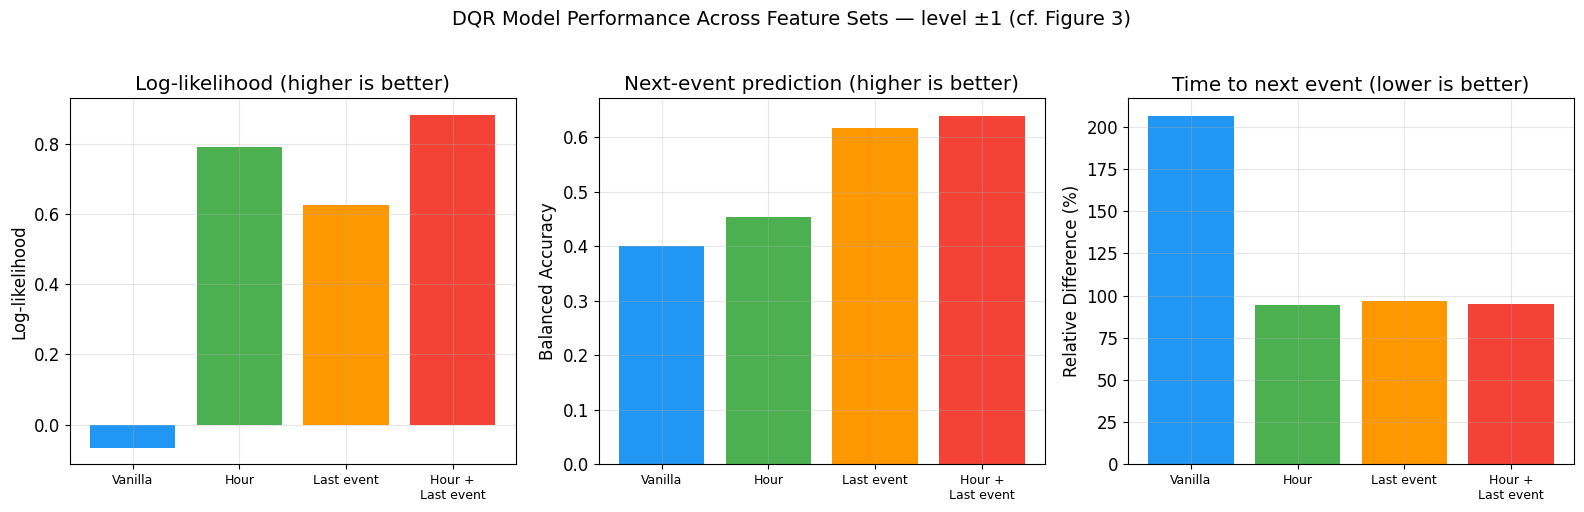

In [154]:
# --- Figure 3 (level ±1 metrics, comparable to paper Figure 3) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
xlabels = ['Vanilla', 'Hour', 'Last event', 'Hour +\nLast event']

# Use level ±1 averages for the figure (clean, comparable to paper)
w1 = level_weights[+1]; w2 = level_weights[-1]; w12 = w1 + w2
lls = [(all_results[(+1,c)]['log_likelihood']*w1    + all_results[(-1,c)]['log_likelihood']*w2)    / w12 for c in configs]
bas = [(all_results[(+1,c)]['balanced_accuracy']*w1 + all_results[(-1,c)]['balanced_accuracy']*w2) / w12 for c in configs]
tds = [(all_results[(+1,c)]['time_relative_diff']*w1+ all_results[(-1,c)]['time_relative_diff']*w2) / w12 for c in configs]

axes[0].bar(range(4), lls,  color=colors)
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(xlabels, fontsize=9)
axes[0].set_ylabel("Log-likelihood"); axes[0].set_title("Log-likelihood (higher is better)")

axes[1].bar(range(4), bas,  color=colors)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].set_ylabel("Balanced Accuracy"); axes[1].set_title("Next-event prediction (higher is better)")

axes[2].bar(range(4), tds,  color=colors)
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(xlabels, fontsize=9)
axes[2].set_ylabel("Relative Difference (%)"); axes[2].set_title("Time to next event (lower is better)")

plt.suptitle("DQR Model Performance Across Feature Sets — level ±1 (cf. Figure 3)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. Excitation Between Events (Figure 1 of the paper)

We compute the **analytical** transition matrix implied by each model's learned conditional
distribution — no simulation required.  For each previous event type $\eta_{k-1}$, we group
the training data by `last_event_id` and compute the expected transition probabilities directly
from the model output (average predicted distribution over that group's observed feature distribution).

- **DQR with last event** ($\mathbf{x}_k = [q_k, \eta_{k-1}]$): explicitly conditions on prior event → diagonal-dominant (cf. Figure 1c).

Key diagnostic: the historical transition matrix is diagonally dominant (each event type tends to follow itself), reflecting self-excitation in real markets.
The DQR model captures this structure because $\eta_{k-1}$ (per-level previous event) is part of its input.

Computing analytical transition matrix for DQR (last_event, all queues)...
  Level -5: 10,168 events
  Level -4: 13,930 events
  Level -3: 25,617 events
  Level -2: 52,979 events
  Level -1: 210,954 events
  Level +1: 181,141 events
  Level +2: 46,971 events
  Level +3: 19,638 events
  Level +4: 11,186 events
  Level +5: 7,767 events


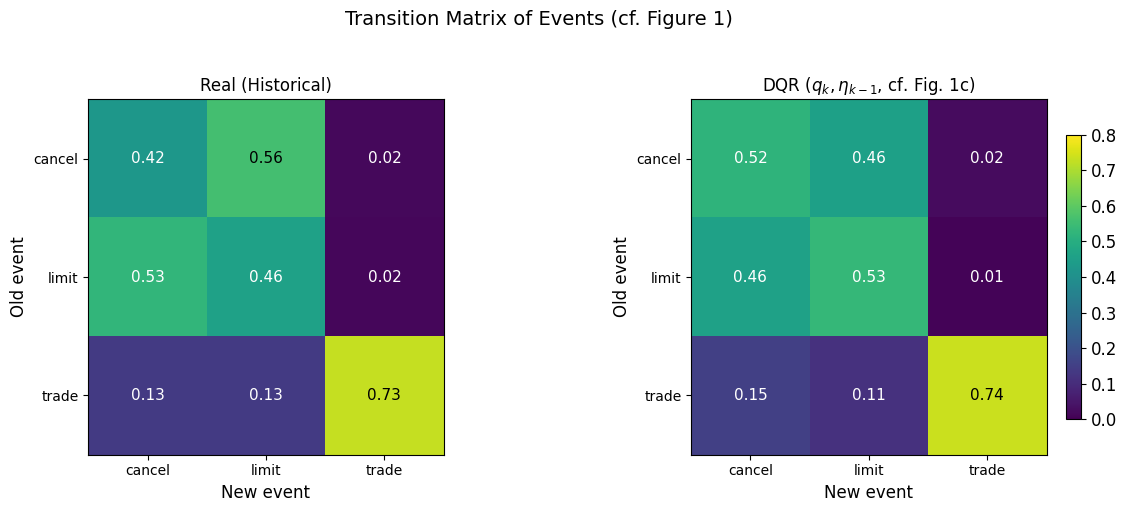


--- Historical ---
                cancel     limit     trade
cancel           0.422     0.561     0.016
limit            0.526     0.459     0.016
trade            0.135     0.134     0.731

--- DQR (last_event) ---
                cancel     limit     trade
cancel           0.521     0.456     0.024
limit            0.457     0.534     0.009
trade            0.152     0.113     0.735


In [155]:
def compute_analytical_transition(model, df, features, device, batch_size=8192):
    """
    Compute the model's implied transition matrix analytically.

    For each η_prev in {L, C, M}, group events by last_event_id == η_prev,
    evaluate the model on those inputs (with last_event_id forced to η_prev),
    and average the normalized intensity vectors.  This gives the model's
    expected P(η_next | η_prev) under the empirical P(q, hour | η_prev) distribution.

    Returns
    -------
    P      : (3, 3) array, P[eta_prev, eta_next]
    counts : (3,) array,   number of data points per group
    """
    model.eval()
    q   = df['q_event'].values.astype(np.float32)
    hr  = df['hour'].values.astype(np.int64)
    # Per-level previous event: df is already filtered to one level
    le  = df['event_id'].shift(1).fillna(0).astype(int).values.astype(np.int64)

    P      = np.zeros((3, 3))
    counts = np.zeros(3)

    for eta_prev in range(3):
        mask = (le == eta_prev)
        n_g  = int(mask.sum())
        if n_g == 0:
            continue
        counts[eta_prev] = n_g

        q_g  = q[mask]
        h_g  = hr[mask]
        le_g = np.full(n_g, eta_prev, dtype=np.int64)   # override to the group's η_prev

        all_probs = []
        for s in range(0, n_g, batch_size):
            e  = min(s + batch_size, n_g)
            xn = torch.tensor(q_g[s:e].reshape(-1, 1), dtype=torch.float32).to(device)
            if features == 'vanilla':
                xc = None
            elif features == 'hour':
                xc = torch.tensor(h_g[s:e].reshape(-1, 1), dtype=torch.long).to(device)
            elif features == 'last_event':
                xc = torch.tensor(le_g[s:e].reshape(-1, 1), dtype=torch.long).to(device)
            elif features == 'both':
                xc = torch.tensor(np.column_stack([h_g[s:e], le_g[s:e]]),
                                  dtype=torch.long).to(device)
            with torch.no_grad():
                lam = model(xn, xc).cpu().numpy()
            Lambda = lam.sum(axis=1, keepdims=True).clip(min=1e-12)
            all_probs.append(lam / Lambda)

        P[eta_prev] = np.vstack(all_probs).mean(axis=0)

    return P, counts


def compute_transition_matrix_hist(seq, n=3):
    """Count consecutive-pair transitions in an event-type sequence."""
    M = np.zeros((n, n), dtype=float)
    for a, b in zip(seq[:-1], seq[1:]):
        if 0 <= a < n and 0 <= b < n:
            M[a, b] += 1.0
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return M / row_sums


def plot_transition_matrices(matrices, titles, labels=['cancel', 'limit', 'trade']):
    n = len(matrices)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=0.8, aspect='equal')
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel("New event"); ax.set_ylabel("Old event")
        ax.set_title(title, fontsize=12); ax.grid(False)
        for i in range(len(labels)):
            for j in range(len(labels)):
                tc = 'black' if mat[i, j] > 0.55 else 'white'
                ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center',
                        fontsize=11, color=tc)
    fig.colorbar(im, ax=axes[-1], shrink=0.8, fraction=0.046, pad=0.04)
    plt.suptitle("Transition Matrix of Events (cf. Figure 1)", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()


# --- Historical transition matrix (from full global event sequence) ---
hist_seq_full = df_train['event_id'].values
M_hist = compute_transition_matrix_hist(hist_seq_full)

# --- Analytical transition matrix for DQR (last_event model, aggregated over all queues) ---
print("Computing analytical transition matrix for DQR (last_event, all queues)...")
M_dqr_total = np.zeros((3, 3))
total_count  = 0.0
for lvl_tm in levels_all:
    df_lvl_tm = df_train[df_train['lvl'] == lvl_tm].reset_index(drop=True)
    P_lvl, counts_lvl = compute_analytical_transition(
        models[(lvl_tm, 'last_event')], df_lvl_tm, 'last_event', device)
    w = float(counts_lvl.sum())
    M_dqr_total += P_lvl * w
    total_count  += w
    print(f"  Level {lvl_tm:+d}: {int(w):,} events")
M_dqr = M_dqr_total / M_dqr_total.sum(axis=1, keepdims=True)

# Internal order: 0=L, 1=C, 2=M.  Reorder to paper display [C, L, M].
p = [1, 0, 2]

plot_transition_matrices(
    [M_hist[np.ix_(p, p)], M_dqr[np.ix_(p, p)]],
    ['Real (Historical)', 'DQR ($q_k, \\eta_{k-1}$, cf. Fig. 1c)'],
    labels=['cancel', 'limit', 'trade']
)

labels_txt = ['cancel', 'limit', 'trade']
for name, M in [('Historical',       M_hist[np.ix_(p, p)]),
                ('DQR (last_event)', M_dqr[np.ix_(p, p)])]:
    print(f"\n--- {name} ---")
    print(f"{'':12s}" + "".join(f"{l:>10s}" for l in labels_txt))
    for i, row_lbl in enumerate(labels_txt):
        print(f"{row_lbl:<12s}" + "".join(f"{M[i,j]:10.3f}" for j in range(3)))

---
## 8. Intraday Seasonality (Figure 2 of the paper)

The DQR model with $h_k$ should reproduce the characteristic **U-shape** of market activity:
higher intensity at open (09:30) and close (15:30), lower at midday.
The vanilla model (QR, no hour feature) depends solely on the current queue size.
It partially captures the open activity — large queues at market open push predicted intensity
up — but it systematically underestimates the end-of-day surge: queue sizes at close are
not large enough on their own to recover the full closing spike.
In contrast, DQR with $h_k$ learns a direct hour-slot embedding and tracks the U-shape
closely, confirming that the intraday rate modulation is not fully explained by queue sizes
alone.

Hour slot               q_min  q_max
9:30-10:30 (Open)         0.0  159.0
10:30-11:30               0.0  201.0
11:30-12:30               0.0  221.0
12:30-13:30 (Lunch)       0.0  132.0
13:30-14:30               0.0  120.0
14:30-15:30               0.0  312.0
15:30-16:00 (Close)       0.0  322.0

Hour slot                 N_M   Duration  Hist [s^-1]   DQR [s^-1]  QR [s^-1]
------------------------------------------------------------------------------
9:30-10:30 (Open)        6649       3600       1.8469       1.5546     2.1808
10:30-11:30              3626       3600       1.0072       1.1399     0.8363
11:30-12:30              4353       3600       1.2092       1.1949     0.7890
12:30-13:30 (Lunch)      3259       3600       0.9053       1.5336     0.6621
13:30-14:30              3000       3600       0.8333       1.5249     0.6775
14:30-15:30              4866       3600       1.3517       1.4155     0.6749
15:30-16:00 (Close)      6729       1800       3.7383       3.4099     0.9340


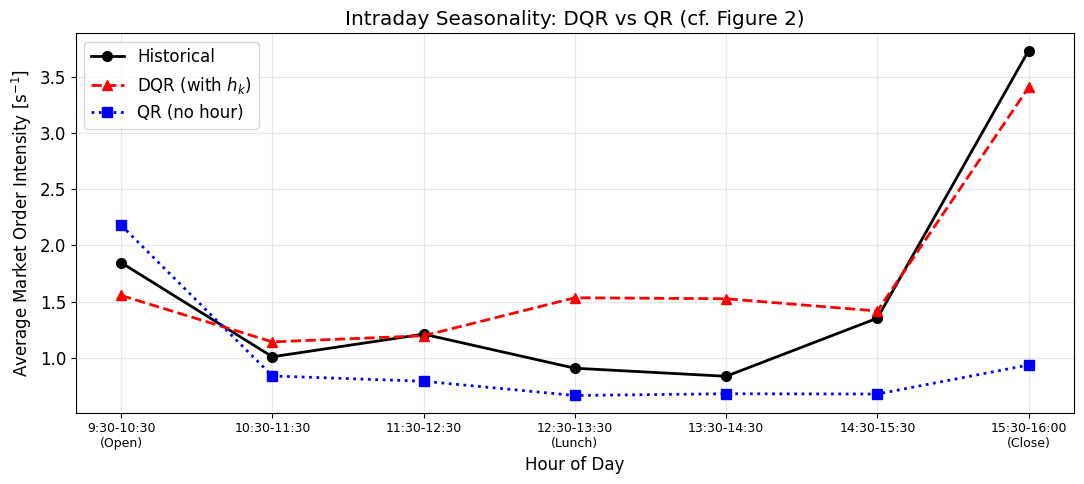

In [156]:
# --- Historical market-order intensity at level ±1 per hour ---
# Use the same slot boundaries as df_train['hour']:
#   slot h covers [MARKET_OPEN_S + h*3600, MARKET_OPEN_S + (h+1)*3600)
#   slot 6 covers [MARKET_OPEN_S + 6*3600, MARKET_CLOSE_S)  => only 1800 s
# This must MATCH the hour assignment in df_train (which uses (time-MARKET_OPEN_S)//3600).

HOUR_LABELS = [
    "9:30-10:30\n(Open)", "10:30-11:30", "11:30-12:30",
    "12:30-13:30\n(Lunch)", "13:30-14:30", "14:30-15:30",
    "15:30-16:00\n(Close)"
]
hours = list(range(7))

hist_intensity = []
hist_debug     = []   # store (n_M, duration) for text output
for h in hours:
    t_start = MARKET_OPEN_S + h * 3600
    t_end   = min(MARKET_OPEN_S + (h + 1) * 3600, MARKET_CLOSE_S)
    duration = float(t_end - t_start)   # 3600 for h=0..5, 1800 for h=6
    # Select M events at level ±1 within this time window
    sub = df[(df['time'] >= t_start) & (df['time'] < t_end) & (df['lvl'].abs() == 1)]
    n_M = int((sub['type'] == 'M').sum())
    hist_intensity.append(n_M / max(duration, 1.0))
    hist_debug.append((n_M, int(duration)))

# --- Model predictions using the ACTUAL queue sizes at each hour ---
# For each hour slot, average predictions from level +1 and level -1 models
# (the most active queues). Each model sees its own x_cat (no level_id needed).
for lvl_s8 in [+1, -1]:
    models[(lvl_s8, 'hour')].eval()
    models[(lvl_s8, 'vanilla')].eval()

avg_dqr  = []
avg_qr   = []
q_ranges = []   # for debug output
for h in hours:
    lam_dqr_all = []
    lam_qr_all  = []
    q_all        = []
    for lvl_s8 in [+1, -1]:
        mask_h = (df_train['hour'] == h) & (df_train['lvl'] == lvl_s8)
        q_h    = df_train.loc[mask_h, 'q_event'].values.astype(np.float32)
        if len(q_h) == 0:
            continue
        xn = torch.tensor(q_h.reshape(-1, 1), dtype=torch.float32).to(device)
        with torch.no_grad():
            # DQR (hour model): x_cat = [hour]
            xc_dqr = torch.tensor(
                np.full((len(q_h), 1), h, dtype=np.int64),
                dtype=torch.long).to(device)
            lam_dqr = models[(lvl_s8, 'hour')](xn, xc_dqr).cpu().numpy()
            lam_dqr_all.extend(lam_dqr[:, 2].tolist())
            # Vanilla model: x_cat = None
            lam_qr = models[(lvl_s8, 'vanilla')](xn, None).cpu().numpy()
            lam_qr_all.extend(lam_qr[:, 2].tolist())
        q_all.extend(q_h.tolist())
    avg_dqr.append(float(np.mean(lam_dqr_all)) if lam_dqr_all else 0.0)
    avg_qr.append(float(np.mean(lam_qr_all))   if lam_qr_all  else 0.0)
    q_ranges.append((float(np.min(q_all)), float(np.max(q_all))) if q_all else (0.0, 0.0))

# --- Text output for debugging ---
print(f"{'Hour slot':<22} {'q_min':>6} {'q_max':>6}")
for i, (lbl, (qmin, qmax)) in enumerate(zip(HOUR_LABELS, q_ranges)):
    print(f"{lbl.replace(chr(10),' '):<22} {qmin:>6.1f} {qmax:>6.1f}")
print(f"\n{'Hour slot':<22} {'N_M':>6} {'Duration':>10} {'Hist [s^-1]':>12} "
      f"{'DQR [s^-1]':>12} {'QR [s^-1]':>10}")
print('-' * 78)
for i, (lbl, (n_M, dur)) in enumerate(zip(HOUR_LABELS, hist_debug)):
    lbl_clean = lbl.replace('\n', ' ')
    print(f"{lbl_clean:<22} {n_M:>6} {dur:>10} {hist_intensity[i]:>12.4f} "
          f"{avg_dqr[i]:>12.4f} {avg_qr[i]:>10.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hours, hist_intensity, 'ko-',  lw=2, ms=7, label='Historical')
ax.plot(hours, avg_dqr,        'r^--', lw=2, ms=7, label=r'DQR (with $h_k$)')
ax.plot(hours, avg_qr,         'bs:',  lw=2, ms=7, label='QR (no hour)')
ax.set_xticks(hours)
ax.set_xticklabels(HOUR_LABELS, fontsize=9)
ax.set_xlabel("Hour of Day")
ax.set_ylabel(r"Average Market Order Intensity [s$^{-1}$]")
ax.set_title("Intraday Seasonality: DQR vs QR (cf. Figure 2)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Summary, Limitations, and Transition to MDQR

### What we demonstrated

1. **The two features capture complementary properties.** The three metrics tell different stories:
   - **Log-likelihood** (overall quality): Both (0.88) $>$ Hour (0.79) $>$ Last event (0.63) $>$ Vanilla ($-0.07$). Combining both features is best, and the hour feature contributes more to the overall NLL than the last-event feature alone.
   - **Balanced accuracy** (which event type comes next): Both (64%) $\approx$ Last event (62%) $\gg$ Hour (45%) $>$ Vanilla (40%). $\eta_{k-1}$ is the dominant driver — knowing the previous event type is what makes next-event type predictable. The hour slot alone barely improves over the baseline.
   - **Timing error** (when the next event arrives): Vanilla (207%) $\gg$ Hour (95%) $\approx$ Last event (97%) $\approx$ Both (95%). $h_k$ is the dominant driver of the arrival rate. Once the hour is included, adding $\eta_{k-1}$ gives negligible further timing improvement. Values remain above the theoretical $\sim 44\%$ floor because a single trading day is insufficient to perfectly calibrate the intensity across all hour–queue-size combinations.

2. **Self-excitation is faithfully captured by $\eta_{k-1}$.** The analytical transition matrix of DQR with last-event closely reproduces the historical diagonal dominance: trade $\to$ trade (0.735 model vs 0.731 historical), cancel $\to$ cancel (0.521 vs 0.422), limit $\to$ limit (0.534 vs 0.459). The vanilla DQR, which does not see $\eta_{k-1}$, produces near-uniform rows across all previous event types.

3. **The timing metric requires filtering LOBSTER burst arrivals.** LOBSTER records many simultaneous events at identical microsecond timestamps (batch arrivals at the exchange level). These produce $\Delta t_k \approx 0$ after clipping and dominate the per-level inter-arrival distribution (median $\Delta t_k = 0.1$ ms at level $\pm 1$). Including them inflates the median relative timing error to tens-of-thousands of percent. Filtering to $\Delta t_k > 1$ ms (retaining $\sim 35\%$ of level-$\pm 1$ events — the genuine independent inter-arrivals) recovers a metric in the 95–207% range, with the theoretical floor of $\sim 44\%$ achievable by a perfectly calibrated Poisson process.

---

### Dataset limitation: single trading day

The paper trains on several weeks of data. With a single day (2012-06-21), three compounding issues arise:

- **Intraday seasonality (Section 8).** Despite having only one observation per hour slot, the DQR model with $h_k$ successfully tracks the historical U-shape (open: 1.55 vs historical 1.85 $s^{-1}$; close: 3.41 vs 3.74 $s^{-1}$). The QR model correctly captures the high-open activity through large queue sizes but fails to predict the close spike, demonstrating that the end-of-day surge is not explained by queue sizes alone. With multiple trading days, each slot would accumulate more diverse examples and the hour embeddings would generalise more robustly across different market conditions.

- **Self-excitation (Section 7).** Because we read the transition matrix analytically from the model's learned conditional probabilities, the DQR model faithfully reproduces the diagonal-dominant structure of the historical transition matrix even on a single day.

- **Generalisation of intensity levels.** With one day, the model cannot distinguish day-specific market conditions (e.g., news events on 2012-06-21) from structural patterns.

---

### Remaining structural limitations

Even with more data, the DQR model treats each queue **independently** — motivating the **MDQR** model in Notebook 3:
- Joint modelling of all $2K$ queues (output dimension $= 3 \times 2K$).
- Cross-level state features: queue sizes at all levels, bid-ask spread, order-flow imbalance.
- Switch to **global** $\Delta t_k$ (time between any order book events) instead of per-level $\Delta t_k$ (paper Section 4.2): this avoids per-level gap problems while capturing cross-level interactions.
- Separate neural network for order-size prediction.